# AI-READI Dataset - Data Fidelity Analysis

**Purpose**: Assess data quality, sampling frequencies, and completeness across all sensor modalities.

This notebook performs a systematic evaluation of:
1. **Sampling frequencies** - How often each sensor records data per patient
2. **Missing data patterns** - Which patients have incomplete modalities
3. **Data quality metrics** - Outliers and anomalies in sampling rates
4. **Clinical data completeness** - Fidelity of surveys, demographics, and lab results

---

## Why This Matters for Data Cleaning

Before building ML models, we need to understand:
- **Which patients to include** - Those with complete, high-quality data
- **Which sensors are reliable** - Consistent sampling rates across patients
- **What data quality issues exist** - Anomalies that need investigation
- **How to stratify analyses** - Account for different data availability

This analysis uses **manifest files** (pre-aggregated metadata) to assess 2,280 participants without downloading 97 GB of raw data.

---

## 1. Setup & Load Manifest Files

In [12]:
# Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Configure plotting
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("✓ Libraries loaded successfully!")

✓ Libraries loaded successfully!


In [13]:
# Load manifest files
manifest_dir = Path('../data/samples/manifests')

print("Loading manifest files...")
print("=" * 80)

# CGM manifest
cgm_manifest = pd.read_csv(manifest_dir / 'manifest_wearable_blood_glucose.tsv', sep='\t')
print(f"✓ CGM manifest: {len(cgm_manifest)} participants")

# ECG manifest
ecg_manifest = pd.read_csv(manifest_dir / 'manifest_cardiac_ecg.tsv', sep='\t')
print(f"✓ ECG manifest: {len(ecg_manifest)} participants")

# Activity monitor manifest
activity_manifest = pd.read_csv(manifest_dir / 'manifest_wearable_activity_monitor.tsv', sep='\t')
print(f"✓ Activity monitor manifest: {len(activity_manifest)} participants")

# Environmental sensor manifest
env_manifest = pd.read_csv(manifest_dir / 'manifest_environment.tsv', sep='\t')
print(f"✓ Environmental sensor manifest: {len(env_manifest)} participants")

# Participants metadata
participants = pd.read_csv(manifest_dir / 'participants.tsv', sep='\t')
print(f"✓ Participants metadata: {len(participants)} participants")

print("=" * 80)
print("\n✓ All manifests loaded successfully!")

Loading manifest files...
✓ CGM manifest: 2245 participants
✓ ECG manifest: 2257 participants
✓ Activity monitor manifest: 2184 participants
✓ Environmental sensor manifest: 2231 participants
✓ Participants metadata: 2280 participants

✓ All manifests loaded successfully!


In [14]:
# Quick preview of manifest structures
print("CGM Manifest Columns:")
print(cgm_manifest.columns.tolist())
print("\nActivity Monitor Manifest Columns:")
print(activity_manifest.columns.tolist())
print("\nParticipants Metadata Columns:")
print(participants.columns.tolist())

CGM Manifest Columns:
['person_id', 'glucose_filepath', 'glucose_level_record_count', 'average_glucose_level_mg_dl', 'glucose_sensor_sampling_duration_days', 'glucose_sensor_id', 'manufacturer', 'manufacturer_model_name']

Activity Monitor Manifest Columns:
['person_id', 'wrist_worn_on', 'dominant_hand', 'heartrate_filepath', 'heartrate_record_count', 'average_heartrate_bpm', 'oxygen_saturation_filepath', 'oxygen_saturation_record_count', 'average_oxygen_saturation_pct', 'stress_level_filepath', 'stress_level_record_count', 'average_stress_level', 'sleep_filepath', 'sleep_record_count', 'average_sleep_hours', 'respiratory_rate_filepath', 'respiratory_rate_record_count', 'average_respiratory_rate_bpm', 'physical_activity_filepath', 'physical_activity_num_days', 'average_daily_activity', 'active_calories_filepath', 'active_calories_record_count', 'average_active_calories_kcal', 'sensor_sampling_duration_days', 'manufacturer', 'manufacturer_model_name']

Participants Metadata Columns:
['p

## 2. CGM Sampling Frequency Analysis

**Continuous Glucose Monitoring (CGM)** - Dexcom G6 sensor

- **Expected**: 1 reading every 5 minutes = 0.2 readings/minute = 288 readings/day
- **Duration**: ~11 days of continuous monitoring
- **Metric**: Calculate per-patient average sampling frequency

In [15]:
# Calculate CGM sampling frequency per patient
cgm_manifest['sampling_freq_per_min'] = (
    cgm_manifest['glucose_level_record_count'] /
    (cgm_manifest['glucose_sensor_sampling_duration_days'] * 1440)  # 1440 minutes per day
)

# Replace infinite values with NaN
cgm_manifest['sampling_freq_per_min'] = cgm_manifest['sampling_freq_per_min'].replace([np.inf, -np.inf], np.nan)

# Count valid data
n_valid = cgm_manifest['sampling_freq_per_min'].notna().sum()
n_total = len(cgm_manifest)

# Display summary statistics
print("CGM Sampling Frequency Statistics:")
print("=" * 80)
print(f"Valid patients: {n_valid} / {n_total} ({n_valid/n_total*100:.1f}%)")
print(f"Mean: {cgm_manifest['sampling_freq_per_min'].mean():.4f} readings/minute")
print(f"Median: {cgm_manifest['sampling_freq_per_min'].median():.4f} readings/minute")
print(f"Std Dev: {cgm_manifest['sampling_freq_per_min'].std():.4f} readings/minute")
print(f"Min: {cgm_manifest['sampling_freq_per_min'].min():.4f} readings/minute")
print(f"Max: {cgm_manifest['sampling_freq_per_min'].max():.4f} readings/minute")
print("\nExpected (Dexcom G6 spec): 0.2000 readings/minute (1 every 5 minutes)")
print("=" * 80)

CGM Sampling Frequency Statistics:
Valid patients: 2245 / 2245 (100.0%)
Mean: 0.1783 readings/minute
Median: 0.1802 readings/minute
Std Dev: 0.0116 readings/minute
Min: 0.0097 readings/minute
Max: 0.1995 readings/minute

Expected (Dexcom G6 spec): 0.2000 readings/minute (1 every 5 minutes)


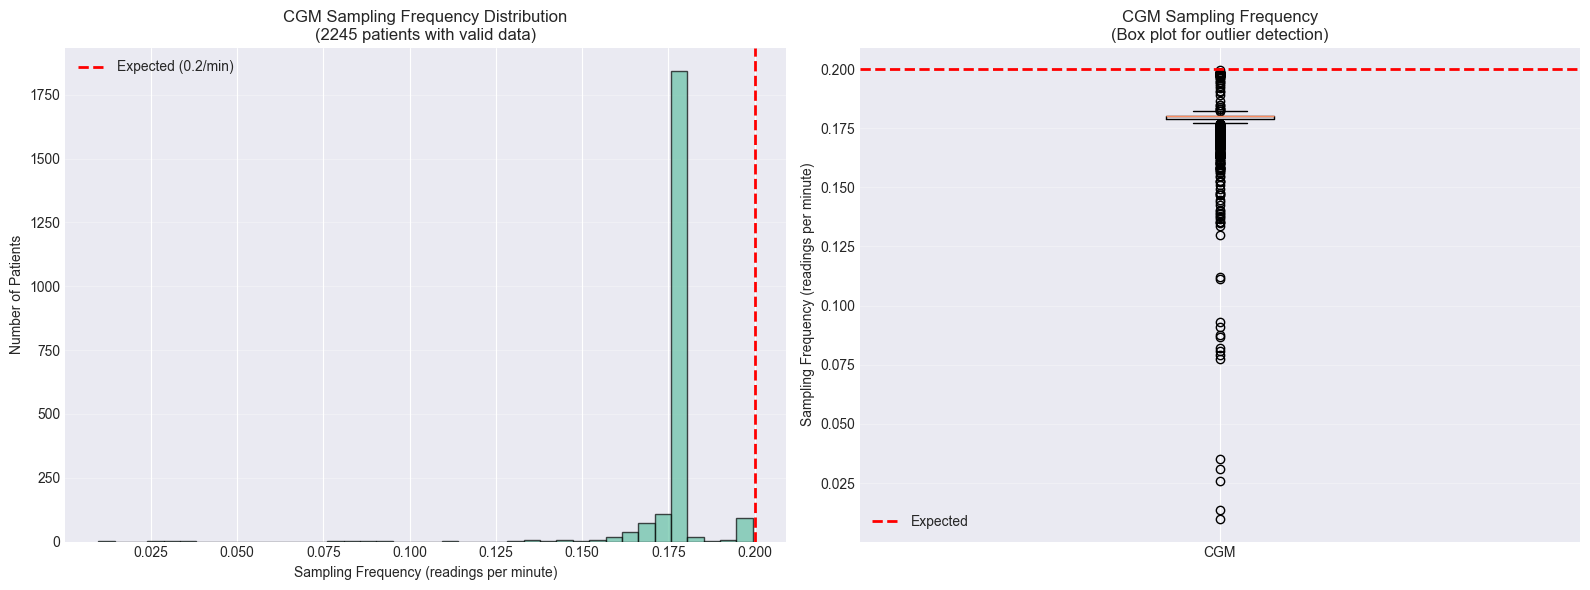

In [16]:
# Create histogram
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Filter out NaN for plotting
cgm_valid = cgm_manifest['sampling_freq_per_min'].dropna()

# Histogram of sampling frequencies
ax1.hist(cgm_valid, bins=40, edgecolor='black', alpha=0.7)
ax1.axvline(0.2, color='red', linestyle='--', linewidth=2, label='Expected (0.2/min)')
ax1.set_xlabel('Sampling Frequency (readings per minute)')
ax1.set_ylabel('Number of Patients')
ax1.set_title(f'CGM Sampling Frequency Distribution\n({len(cgm_valid)} patients with valid data)')
ax1.legend()
ax1.grid(axis='y', alpha=0.3)

# Box plot for outlier detection
ax2.boxplot(cgm_valid, vert=True)
ax2.axhline(0.2, color='red', linestyle='--', linewidth=2, label='Expected')
ax2.set_ylabel('Sampling Frequency (readings per minute)')
ax2.set_title('CGM Sampling Frequency\n(Box plot for outlier detection)')
ax2.set_xticklabels(['CGM'])
ax2.legend()
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [17]:
# Identify outliers (patients with unusual sampling rates)
cgm_mean = cgm_manifest['sampling_freq_per_min'].mean()
cgm_std = cgm_manifest['sampling_freq_per_min'].std()

# Identify outliers (excluding NaN values)
valid_mask = cgm_manifest['sampling_freq_per_min'].notna()
outliers = cgm_manifest[
    valid_mask &
    ((cgm_manifest['sampling_freq_per_min'] < cgm_mean - 2 * cgm_std) |
     (cgm_manifest['sampling_freq_per_min'] > cgm_mean + 2 * cgm_std))
]

print(f"CGM Outliers (±2 std dev from mean):")
print(f"Total outliers: {len(outliers)} / {valid_mask.sum()} valid patients ({len(outliers)/valid_mask.sum()*100:.1f}%)")

if len(outliers) > 0:
    print("\nOutlier details:")
    print(outliers[['person_id', 'glucose_level_record_count', 
                   'glucose_sensor_sampling_duration_days', 'sampling_freq_per_min']].head(10))

CGM Outliers (±2 std dev from mean):
Total outliers: 41 / 2245 valid patients (1.8%)

Outlier details:
     person_id  glucose_level_record_count  \
62        1063                        1782   
109       1111                          28   
317       1324                        1156   
491       1504                         250   
699       1714                         880   
708       1723                         975   
719       1734                        1057   
789       1804                        1459   
810       4028                         998   
814       4034                          89   

     glucose_sensor_sampling_duration_days  sampling_freq_per_min  
62                                       8               0.154688  
109                                      2               0.009722  
317                                      6               0.133796  
491                                      2               0.086806  
699                                      4        

## 3. Wearable Activity Monitor Sampling Frequencies

**Garmin Wearable Sensors** measure:
- Heart rate
- Oxygen saturation (SpO2)
- Stress level
- Sleep
- Respiratory rate
- Physical activity

In [18]:
# Calculate sampling frequencies for each wearable sensor
sensor_types = {
    'Heart Rate': 'heartrate_record_count',
    'Oxygen Saturation': 'oxygen_saturation_record_count',
    'Stress Level': 'stress_level_record_count',
    'Sleep': 'sleep_record_count',
    'Respiratory Rate': 'respiratory_rate_record_count'
}

# Calculate frequencies (readings per minute)
for sensor_name, count_col in sensor_types.items():
    freq_col = f'{sensor_name.lower().replace(" ", "_")}_freq_per_min'
    activity_manifest[freq_col] = (
        activity_manifest[count_col] /
        (activity_manifest['sensor_sampling_duration_days'] * 1440)
    )
    # Replace inf with NaN immediately after calculation
    activity_manifest[freq_col] = activity_manifest[freq_col].replace([np.inf, -np.inf], np.nan)

# Physical activity is measured in days, not continuous readings
activity_manifest['physical_activity_days'] = activity_manifest['physical_activity_num_days']

print("✓ Sampling frequencies calculated for all wearable sensors")

✓ Sampling frequencies calculated for all wearable sensors


In [19]:
# Summary statistics for each sensor
print("Wearable Sensor Sampling Frequency Statistics:")
print("=" * 80)

for sensor_name in sensor_types.keys():
    freq_col = f'{sensor_name.lower().replace(" ", "_")}_freq_per_min'
    if freq_col in activity_manifest.columns:
        # Filter out infinite values
        valid_data = activity_manifest[freq_col].replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(valid_data) > 0:
            print(f"\n{sensor_name}:")
            print(f"  Valid patients: {len(valid_data)} / {len(activity_manifest)}")
            print(f"  Mean: {valid_data.mean():.4f} readings/minute")
            print(f"  Median: {valid_data.median():.4f} readings/minute")
            print(f"  Std Dev: {valid_data.std():.4f} readings/minute")
            print(f"  Range: [{valid_data.min():.4f}, {valid_data.max():.4f}]")
        else:
            print(f"\n{sensor_name}: No valid data")

print("\n" + "=" * 80)

Wearable Sensor Sampling Frequency Statistics:

Heart Rate:
  Valid patients: 2104 / 2184
  Mean: 0.4564 readings/minute
  Median: 0.4870 readings/minute
  Std Dev: 0.1463 readings/minute
  Range: [0.0014, 0.7613]

Oxygen Saturation:
  Valid patients: 1631 / 2184
  Mean: 0.0818 readings/minute
  Median: 0.0809 readings/minute
  Std Dev: 0.0507 readings/minute
  Range: [0.0000, 0.7931]

Stress Level:
  Valid patients: 2103 / 2184
  Mean: 0.9210 readings/minute
  Median: 0.9374 readings/minute
  Std Dev: 0.0891 readings/minute
  Range: [0.0076, 1.9193]

Sleep:
  Valid patients: 2104 / 2184
  Mean: 0.0112 readings/minute
  Median: 0.0114 readings/minute
  Std Dev: 0.0048 readings/minute
  Range: [0.0000, 0.0503]

Respiratory Rate:
  Valid patients: 2104 / 2184
  Mean: 0.9201 readings/minute
  Median: 0.9368 readings/minute
  Std Dev: 0.0891 readings/minute
  Range: [0.0069, 1.9185]



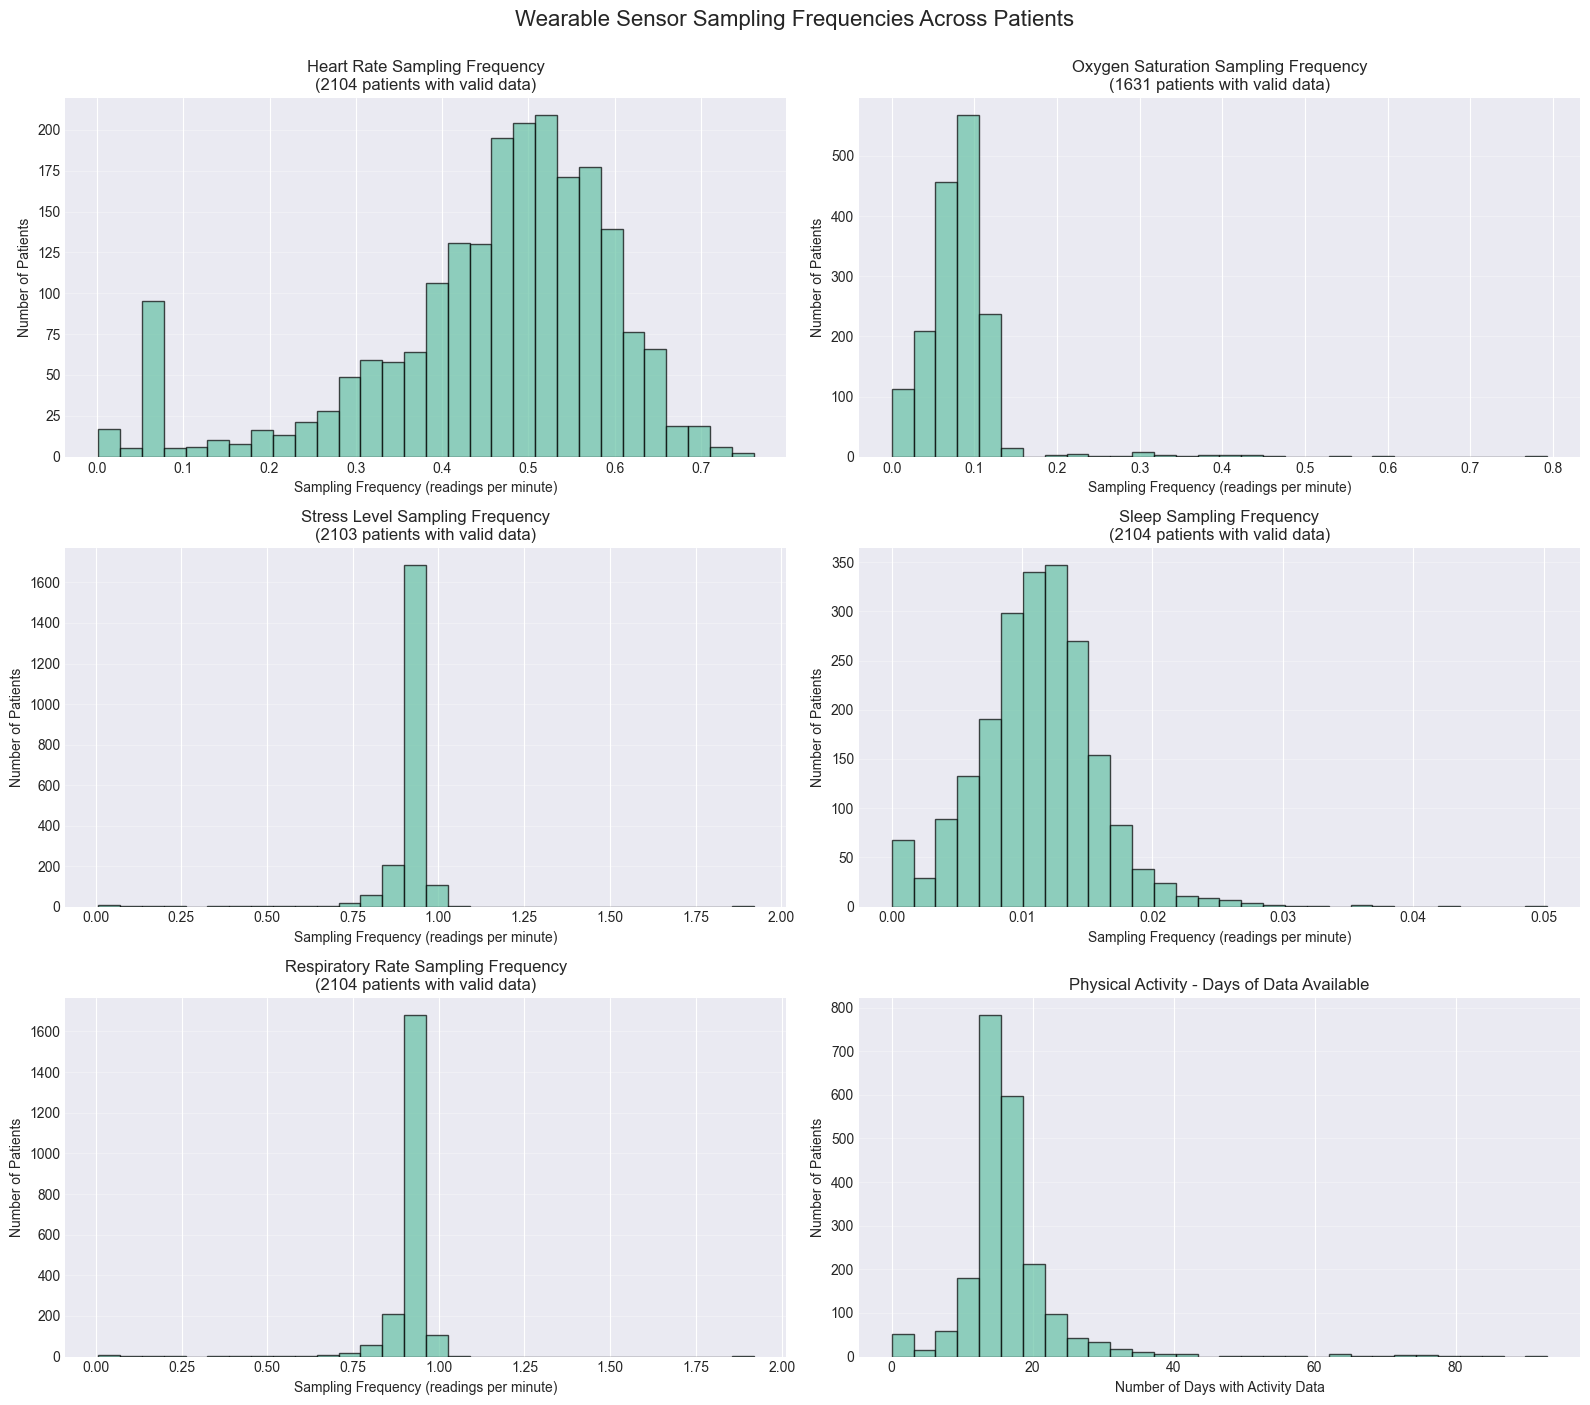

In [20]:
# Create histograms for each wearable sensor
fig, axes = plt.subplots(3, 2, figsize=(16, 14))
axes = axes.flatten()

for idx, sensor_name in enumerate(sensor_types.keys()):
    freq_col = f'{sensor_name.lower().replace(" ", "_")}_freq_per_min'
    
    if freq_col in activity_manifest.columns:
        # Filter out NaN and infinite values
        valid_data = activity_manifest[freq_col].replace([np.inf, -np.inf], np.nan).dropna()
        
        if len(valid_data) > 0:
            axes[idx].hist(valid_data, bins=30, edgecolor='black', alpha=0.7)
            axes[idx].set_xlabel('Sampling Frequency (readings per minute)')
            axes[idx].set_ylabel('Number of Patients')
            axes[idx].set_title(f'{sensor_name} Sampling Frequency\n({len(valid_data)} patients with valid data)')
            axes[idx].grid(axis='y', alpha=0.3)
        else:
            axes[idx].text(0.5, 0.5, 'No valid data', ha='center', va='center')
            axes[idx].set_title(f'{sensor_name} Sampling Frequency')

# Physical activity (measured in days, not continuous)
axes[5].hist(activity_manifest['physical_activity_days'].dropna(), bins=30,
            edgecolor='black', alpha=0.7)
axes[5].set_xlabel('Number of Days with Activity Data')
axes[5].set_ylabel('Number of Patients')
axes[5].set_title('Physical Activity - Days of Data Available')
axes[5].grid(axis='y', alpha=0.3)

plt.suptitle('Wearable Sensor Sampling Frequencies Across Patients', 
            fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

## 4. Environmental Sensor Sampling Frequency

**Lee Lab Anura Environmental Sensors** measure:
- Temperature
- Humidity  
- Light levels (LCH)
- Particulate matter (PM)
- Volatile organic compounds (VOC)
- Nitrogen oxides (NOX)

**Note**: Manifest contains total observation count, not per-variable breakdown. 
For detailed per-variable analysis, raw CSV files would need to be sampled.

In [21]:
# Calculate overall environmental sensor sampling frequency
env_manifest['sampling_freq_per_min'] = (
    env_manifest['number_of_observations'] /
    (env_manifest['sensor_sampling_extent_in_days'] * 1440)
)

# Replace infinite values with NaN
env_manifest['sampling_freq_per_min'] = env_manifest['sampling_freq_per_min'].replace([np.inf, -np.inf], np.nan)

# Count valid data
n_valid = env_manifest['sampling_freq_per_min'].notna().sum()
n_total = len(env_manifest)

print("Environmental Sensor Sampling Frequency Statistics:")
print("=" * 80)
print(f"Valid patients: {n_valid} / {n_total} ({n_valid/n_total*100:.1f}%)")
print(f"Mean: {env_manifest['sampling_freq_per_min'].mean():.4f} readings/minute")
print(f"Median: {env_manifest['sampling_freq_per_min'].median():.4f} readings/minute")
print(f"Std Dev: {env_manifest['sampling_freq_per_min'].std():.4f} readings/minute")
print(f"Min: {env_manifest['sampling_freq_per_min'].min():.4f} readings/minute")
print(f"Max: {env_manifest['sampling_freq_per_min'].max():.4f} readings/minute")
print("\nNote: This is the overall sampling rate across all environmental variables.")
print("Individual variables (temp, humidity, VOC, NOX, PM) may have different rates.")
print("=" * 80)

Environmental Sensor Sampling Frequency Statistics:
Valid patients: 2224 / 2231 (99.7%)
Mean: 11.9962 readings/minute
Median: 12.0002 readings/minute
Std Dev: 0.2553 readings/minute
Min: 6.4792 readings/minute
Max: 17.4236 readings/minute

Note: This is the overall sampling rate across all environmental variables.
Individual variables (temp, humidity, VOC, NOX, PM) may have different rates.


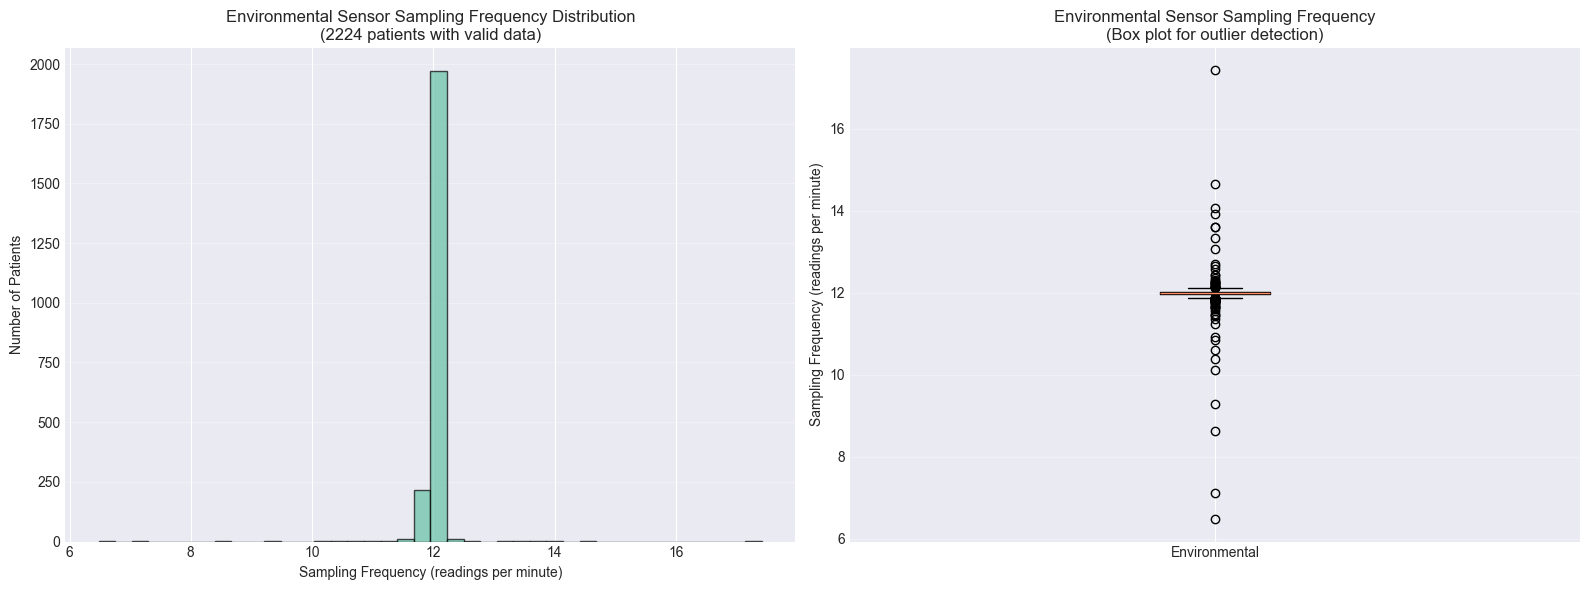

In [22]:
# Histogram of environmental sensor sampling frequencies
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Filter out NaN for plotting
env_valid = env_manifest['sampling_freq_per_min'].dropna()

# Histogram
ax1.hist(env_valid, bins=40, edgecolor='black', alpha=0.7)
ax1.set_xlabel('Sampling Frequency (readings per minute)')
ax1.set_ylabel('Number of Patients')
ax1.set_title(f'Environmental Sensor Sampling Frequency Distribution\n({len(env_valid)} patients with valid data)')
ax1.grid(axis='y', alpha=0.3)

# Box plot
ax2.boxplot(env_valid, vert=True)
ax2.set_ylabel('Sampling Frequency (readings per minute)')
ax2.set_title('Environmental Sensor Sampling Frequency\n(Box plot for outlier detection)')
ax2.set_xticklabels(['Environmental'])
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [23]:
# Identify environmental sensor outliers
env_mean = env_manifest['sampling_freq_per_min'].mean()
env_std = env_manifest['sampling_freq_per_min'].std()

# Identify outliers (excluding NaN values)
valid_mask = env_manifest['sampling_freq_per_min'].notna()
env_outliers = env_manifest[
    valid_mask &
    ((env_manifest['sampling_freq_per_min'] < env_mean - 2 * env_std) |
     (env_manifest['sampling_freq_per_min'] > env_mean + 2 * env_std))
]

print(f"Environmental Sensor Outliers (±2 std dev):")
print(f"Total outliers: {len(env_outliers)} / {valid_mask.sum()} valid patients ({len(env_outliers)/valid_mask.sum()*100:.1f}%)")

if len(env_outliers) > 0:
    print("\nOutlier details:")
    print(env_outliers[['person_id', 'number_of_observations', 
                        'sensor_sampling_extent_in_days', 'sampling_freq_per_min']].head(10))

Environmental Sensor Outliers (±2 std dev):
Total outliers: 25 / 2224 valid patients (1.1%)

Outlier details:
      person_id  number_of_observations  sensor_sampling_extent_in_days  \
107        1110                   14732                             0.9   
207        1212                   10942                             0.6   
387        1398                   14820                             0.9   
501        1515                    2111                             0.1   
568        1583                    6011                             0.3   
751        1768                    5759                             0.3   
774        1791                    3057                             0.2   
1113       4346                     933                             0.1   
1131       4364                    1339                             0.1   
1320       4561                   11338                             0.7   

      sampling_freq_per_min  
107               11.367284  
207 

## 5. ECG Data Fidelity

**12-Lead ECG (Philips PageWriter TC30)**:
- **Type**: Single snapshot recording (not continuous monitoring)
- **Duration**: 11 seconds per recording
- **Sampling rate**: 500 Hz (fixed by device)
- **Focus**: Assess data completeness and derived metric quality

In [24]:
# ECG data availability
print("ECG Data Summary:")
print("=" * 80)
print(f"Patients with ECG data: {len(ecg_manifest)} / 2280 ({len(ecg_manifest)/2280*100:.1f}%)")
print(f"Sampling rate: 500 Hz (fixed by device)")
print(f"Recording duration: 11 seconds")
print(f"Total samples per recording: 5,500 per lead")
print(f"Number of leads: 12 (I, II, III, aVR, aVL, aVF, V1-V6)")
print("=" * 80)

ECG Data Summary:
Patients with ECG data: 2257 / 2280 (99.0%)
Sampling rate: 500 Hz (fixed by device)
Recording duration: 11 seconds
Total samples per recording: 5,500 per lead
Number of leads: 12 (I, II, III, aVR, aVL, aVF, V1-V6)


In [25]:
# Analyze derived ECG metrics completeness
ecg_metrics = ['Rate', 'PR', 'QRSD', 'QT', 'QTc', 'P', 'QRS', 'T']
available_metrics = [m for m in ecg_metrics if m in ecg_manifest.columns]

print("ECG Derived Metrics Completeness:")
print("=" * 80)

for metric in available_metrics:
    n_valid = ecg_manifest[metric].notna().sum()
    pct_valid = (n_valid / len(ecg_manifest)) * 100
    print(f"{metric:10s}: {n_valid:4d} / {len(ecg_manifest)} ({pct_valid:.1f}% complete)")

print("=" * 80)

ECG Derived Metrics Completeness:
Rate      : 2257 / 2257 (100.0% complete)
PR        : 2219 / 2257 (98.3% complete)
QRSD      : 2257 / 2257 (100.0% complete)
QT        : 2257 / 2257 (100.0% complete)
QTc       : 2257 / 2257 (100.0% complete)
P         : 2212 / 2257 (98.0% complete)
QRS       : 2257 / 2257 (100.0% complete)
T         : 2247 / 2257 (99.6% complete)


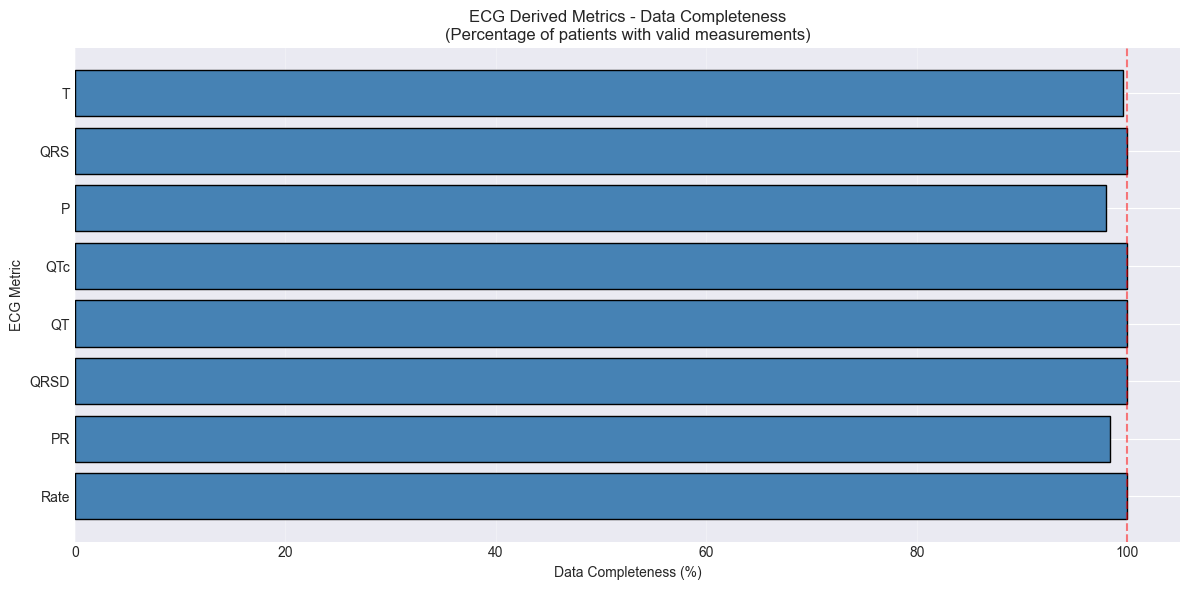

In [26]:
# Visualize ECG metric completeness
completeness_data = []
for metric in available_metrics:
    pct_complete = (ecg_manifest[metric].notna().sum() / len(ecg_manifest)) * 100
    completeness_data.append({'Metric': metric, 'Completeness (%)': pct_complete})

completeness_df = pd.DataFrame(completeness_data)

plt.figure(figsize=(12, 6))
plt.barh(completeness_df['Metric'], completeness_df['Completeness (%)'], 
        color='steelblue', edgecolor='black')
plt.xlabel('Data Completeness (%)')
plt.ylabel('ECG Metric')
plt.title('ECG Derived Metrics - Data Completeness\n(Percentage of patients with valid measurements)')
plt.xlim([0, 105])
plt.axvline(100, color='red', linestyle='--', alpha=0.5)
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

## 6. Missing Data Analysis (Per-Patient)

**Goal**: Identify which patients have incomplete multi-modal data.

This informs:
- **Patient selection** - Which patients to include in multi-modal analyses
- **Data stratification** - How to group patients by data availability
- **Quality thresholds** - Minimum completeness criteria for ML models

In [27]:
# Analyze modality availability per patient
modality_columns = {
    'cardiac_ecg': 'ECG',
    'clinical_data': 'Clinical',
    'wearable_blood_glucose': 'CGM',
    'wearable_activity_monitor': 'Activity',
    'environment': 'Environmental'
}

# Check which columns exist
available_modalities = {k: v for k, v in modality_columns.items() if k in participants.columns}

print("Modality Availability Analysis:")
print("=" * 80)

for col, name in available_modalities.items():
    n_with_data = participants[col].sum()
    pct_with_data = (n_with_data / len(participants)) * 100
    print(f"{name:20s}: {n_with_data:4d} / {len(participants)} ({pct_with_data:.1f}% have data)")

print("=" * 80)

Modality Availability Analysis:
ECG                 : 2251 / 2280 (98.7% have data)
Clinical            : 2280 / 2280 (100.0% have data)
CGM                 : 2245 / 2280 (98.5% have data)
Activity            : 2184 / 2280 (95.8% have data)
Environmental       : 2231 / 2280 (97.9% have data)


In [28]:
# Count missing modalities per patient
modality_cols = list(available_modalities.keys())
participants['n_missing_modalities'] = participants[modality_cols].apply(
    lambda row: (~row.astype(bool)).sum(), axis=1
)

participants['n_available_modalities'] = participants[modality_cols].apply(
    lambda row: row.astype(bool).sum(), axis=1
)

print("\nPer-Patient Missing Modality Statistics:")
print("=" * 80)
print(participants['n_missing_modalities'].value_counts().sort_index())
print("=" * 80)


Per-Patient Missing Modality Statistics:
n_missing_modalities
0    2113
1     145
2       6
3      12
4       4
Name: count, dtype: int64


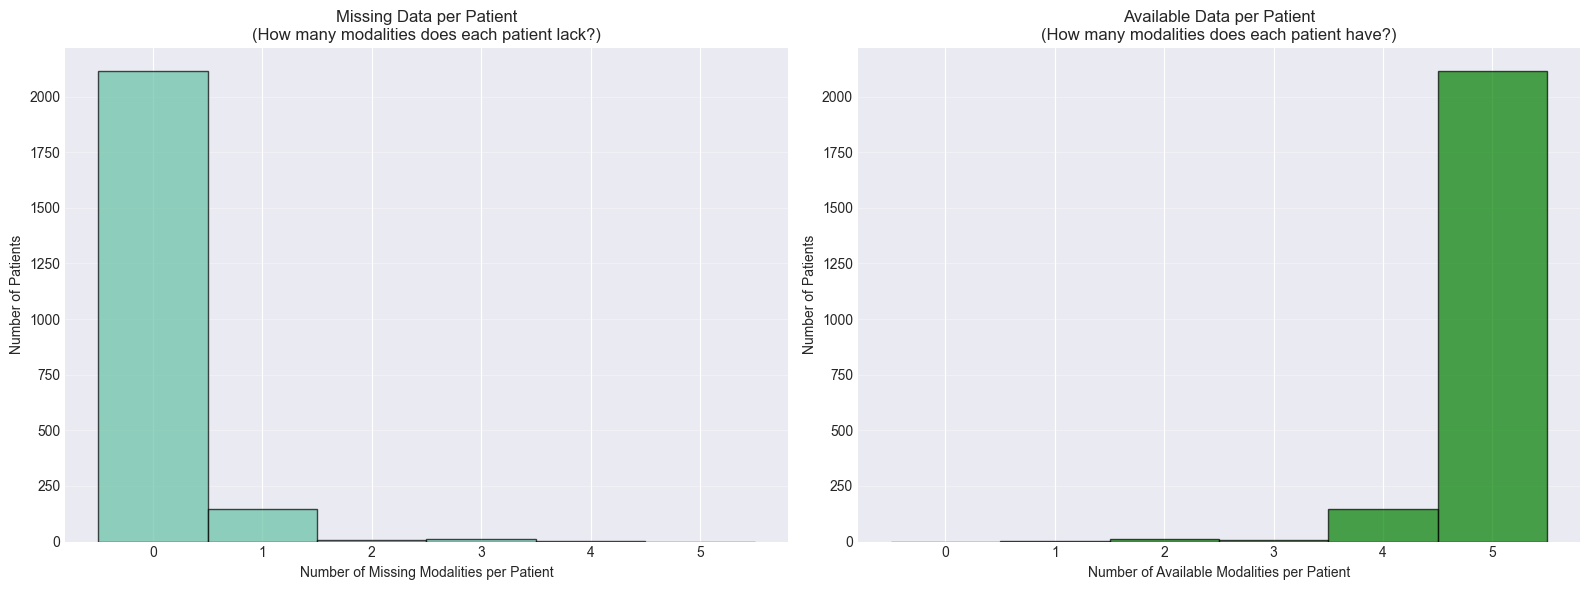

In [29]:
# Histogram of missing modalities per patient
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Missing modalities
ax1.hist(participants['n_missing_modalities'], bins=range(0, len(modality_cols) + 2),
        edgecolor='black', alpha=0.7, align='left')
ax1.set_xlabel('Number of Missing Modalities per Patient')
ax1.set_ylabel('Number of Patients')
ax1.set_title('Missing Data per Patient\n(How many modalities does each patient lack?)')
ax1.set_xticks(range(0, len(modality_cols) + 1))
ax1.grid(axis='y', alpha=0.3)

# Available modalities
ax2.hist(participants['n_available_modalities'], bins=range(0, len(modality_cols) + 2),
        edgecolor='black', alpha=0.7, align='left', color='green')
ax2.set_xlabel('Number of Available Modalities per Patient')
ax2.set_ylabel('Number of Patients')
ax2.set_title('Available Data per Patient\n(How many modalities does each patient have?)')
ax2.set_xticks(range(0, len(modality_cols) + 1))
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

In [30]:
# Identify patients with complete multi-modal data
complete_patients = participants[participants['n_missing_modalities'] == 0]

print("\nMulti-Modal Data Completeness:")
print("=" * 80)
print(f"Patients with ALL modalities: {len(complete_patients)} / {len(participants)} ({len(complete_patients)/len(participants)*100:.1f}%)")
print(f"Patients missing 1 modality: {(participants['n_missing_modalities'] == 1).sum()}")
print(f"Patients missing 2+ modalities: {(participants['n_missing_modalities'] >= 2).sum()}")
print("=" * 80)

print("\n✓ Recommendation for ML modeling:")
print(f"  - Use {len(complete_patients)} patients with complete data for multi-modal models")
print(f"  - Consider single-modality models for patients missing some data")


Multi-Modal Data Completeness:
Patients with ALL modalities: 2113 / 2280 (92.7%)
Patients missing 1 modality: 145
Patients missing 2+ modalities: 22

✓ Recommendation for ML modeling:
  - Use 2113 patients with complete data for multi-modal models
  - Consider single-modality models for patients missing some data


## 7. Non-Frequent Measurements Fidelity

**Clinical Data** (OMOP CDM format):
- Demographics (person table)
- Survey responses (observation table)
- Lab results (measurement table)
- Medical history (condition_occurrence table)

**Note**: Using existing clinical samples for analysis (already downloaded).

In [31]:
# Load clinical data samples
clinical_data_dir = Path('../data/samples')

print("Loading clinical data samples...")

clinical_files = {
    'Person (Demographics)': 'person_sample.csv',
    'Observation (Surveys)': 'observation_sample.csv',
    'Measurement (Lab Results)': 'measurement_sample.csv'
}

clinical_dfs = {}
for name, filename in clinical_files.items():
    filepath = clinical_data_dir / filename
    if filepath.exists():
        clinical_dfs[name] = pd.read_csv(filepath)
        print(f"✓ {name}: {len(clinical_dfs[name])} rows, {len(clinical_dfs[name].columns)} columns")
    else:
        print(f"⚠️  {name}: File not found at {filepath}")

print("\n✓ Clinical data samples loaded successfully")

Loading clinical data samples...
✓ Person (Demographics): 100 rows, 18 columns
✓ Observation (Surveys): 1000 rows, 22 columns
✓ Measurement (Lab Results): 1000 rows, 26 columns

✓ Clinical data samples loaded successfully


In [32]:
# Analyze missing values in each clinical table
for table_name, df in clinical_dfs.items():
    print(f"\n{'=' * 80}")
    print(f"{table_name} - Missing Data Analysis")
    print(f"{'=' * 80}")
    
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    
    # Show top 10 columns with most missing data
    top_missing = missing_pct[missing_pct > 0].head(10)
    
    if len(top_missing) > 0:
        print("\nTop 10 columns with missing data:")
        for col, pct in top_missing.items():
            print(f"  {col:40s}: {pct:6.2f}% missing")
    else:
        print("✓ No missing data in this table!")
    
    print(f"\nOverall completeness: {100 - missing_pct.mean():.2f}%")


Person (Demographics) - Missing Data Analysis
✓ No missing data in this table!

Overall completeness: 100.00%

Observation (Surveys) - Missing Data Analysis

Top 10 columns with missing data:
  unit_source_value                       : 100.00% missing
  value_as_number                         :  24.70% missing

Overall completeness: 94.33%

Measurement (Lab Results) - Missing Data Analysis

Top 10 columns with missing data:
  range_high                              : 100.00% missing
  value_source_value                      : 100.00% missing
  range_low                               : 100.00% missing

Overall completeness: 88.46%


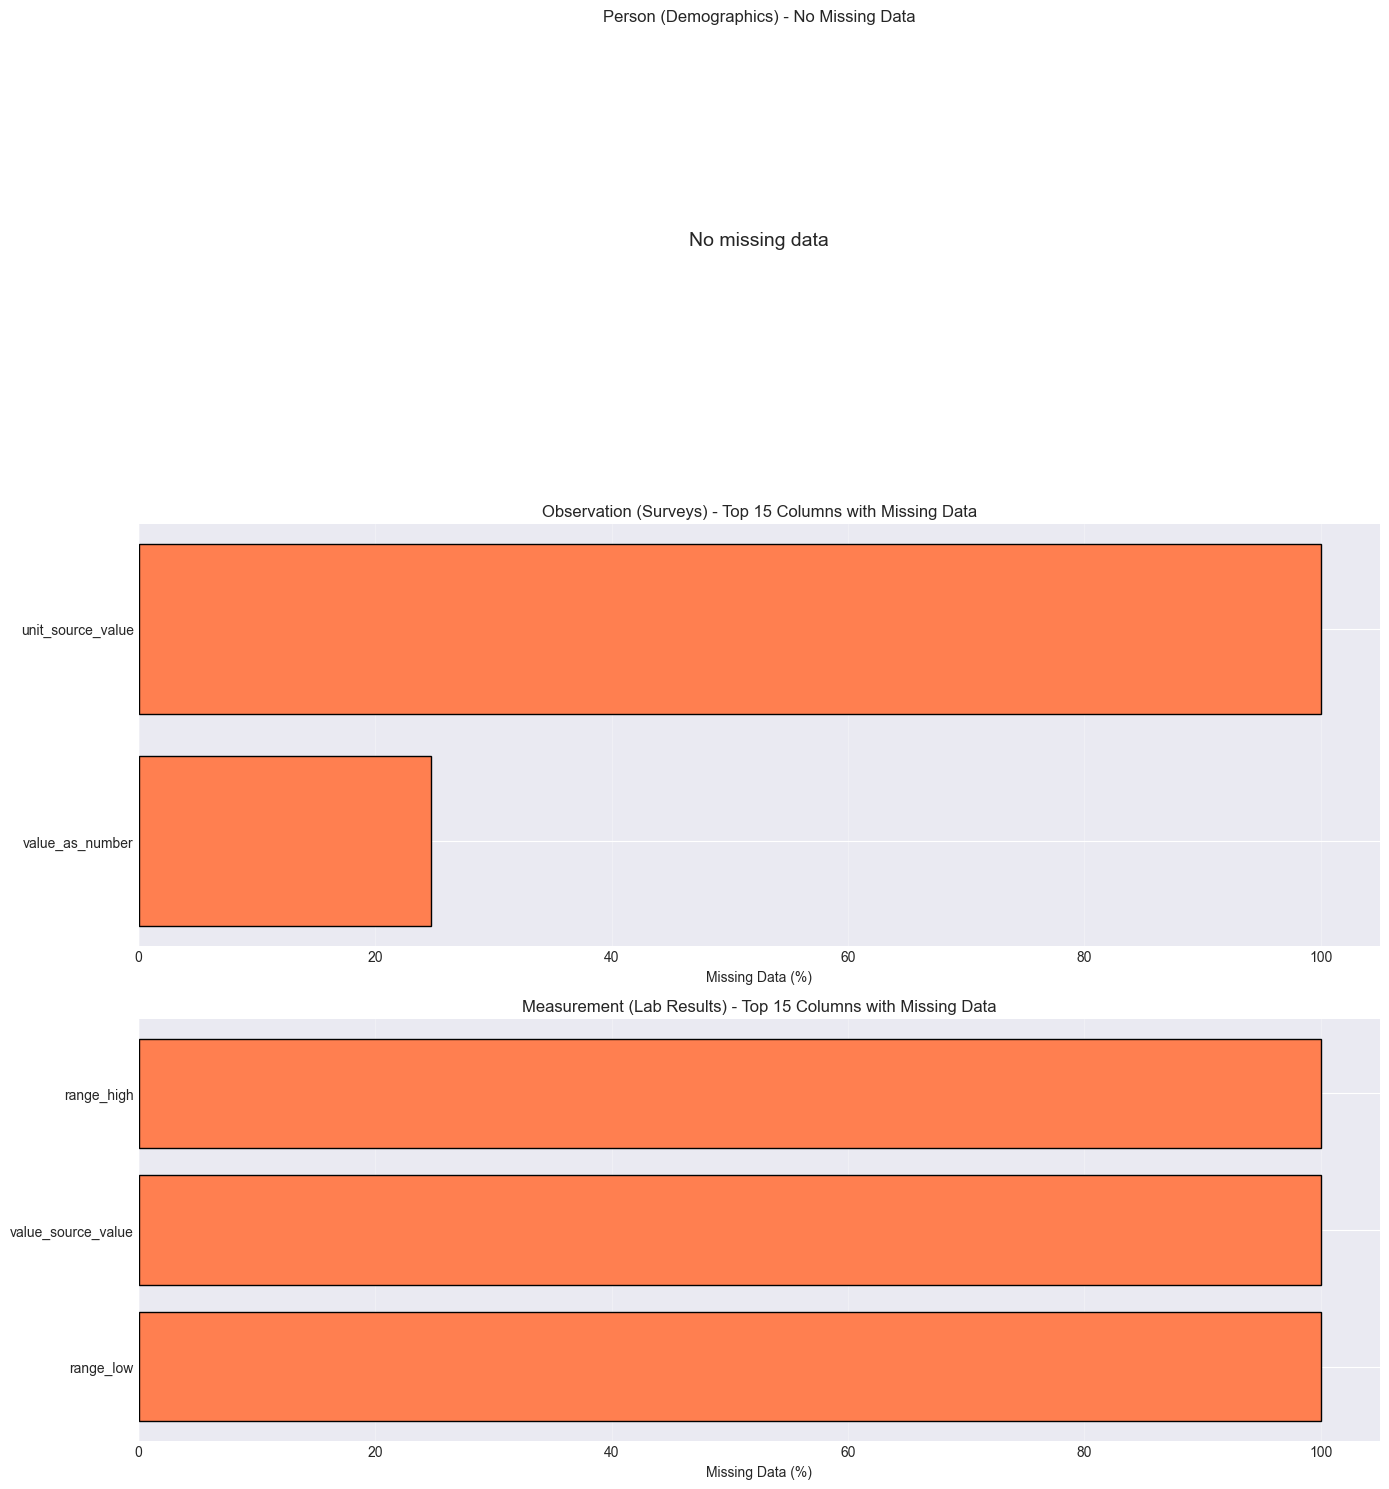

In [33]:
# Visualize missing data patterns
fig, axes = plt.subplots(len(clinical_dfs), 1, figsize=(14, 5 * len(clinical_dfs)))

if len(clinical_dfs) == 1:
    axes = [axes]

for idx, (table_name, df) in enumerate(clinical_dfs.items()):
    missing_pct = (df.isnull().sum() / len(df) * 100).sort_values(ascending=False)
    top_missing = missing_pct[missing_pct > 0].head(15)
    
    if len(top_missing) > 0:
        axes[idx].barh(range(len(top_missing)), top_missing.values, color='coral', edgecolor='black')
        axes[idx].set_yticks(range(len(top_missing)))
        axes[idx].set_yticklabels(top_missing.index)
        axes[idx].set_xlabel('Missing Data (%)')
        axes[idx].set_title(f'{table_name} - Top 15 Columns with Missing Data')
        axes[idx].grid(axis='x', alpha=0.3)
        axes[idx].invert_yaxis()
    else:
        axes[idx].text(0.5, 0.5, 'No missing data', ha='center', va='center', fontsize=14)
        axes[idx].set_title(f'{table_name} - No Missing Data')
        axes[idx].axis('off')

plt.tight_layout()
plt.show()

## 8. Summary & Comparison

**Comprehensive overview** of data quality across all modalities.

In [34]:
# Create comprehensive summary table
# Use safe calculations that ignore NaN
cgm_valid_data = cgm_manifest['sampling_freq_per_min'].dropna()
env_valid_data = env_manifest['sampling_freq_per_min'].dropna()

summary_data = [
    {
        'Modality': 'CGM (Glucose)',
        'Patients with Data': len(cgm_manifest),
        'Coverage (%)': len(cgm_manifest) / 2280 * 100,
        'Avg Sampling Rate': f"{cgm_valid_data.mean():.4f}/min" if len(cgm_valid_data) > 0 else 'N/A',
        'Median Duration (days)': cgm_manifest['glucose_sensor_sampling_duration_days'].median(),
        'Data Quality': 'High' if len(cgm_valid_data) > 0 and cgm_valid_data.std() < 0.01 else 'Moderate'
    },
    {
        'Modality': 'ECG (Cardiac)',
        'Patients with Data': len(ecg_manifest),
        'Coverage (%)': len(ecg_manifest) / 2280 * 100,
        'Avg Sampling Rate': '500 Hz (snapshot)',
        'Median Duration (days)': 'N/A (11 sec)',
        'Data Quality': 'High'
    },
    {
        'Modality': 'Activity Monitor',
        'Patients with Data': len(activity_manifest),
        'Coverage (%)': len(activity_manifest) / 2280 * 100,
        'Avg Sampling Rate': 'Variable',
        'Median Duration (days)': activity_manifest['sensor_sampling_duration_days'].median(),
        'Data Quality': 'Moderate'
    },
    {
        'Modality': 'Environmental',
        'Patients with Data': len(env_manifest),
        'Coverage (%)': len(env_manifest) / 2280 * 100,
        'Avg Sampling Rate': f"{env_valid_data.mean():.4f}/min" if len(env_valid_data) > 0 else 'N/A',
        'Median Duration (days)': env_manifest['sensor_sampling_extent_in_days'].median(),
        'Data Quality': 'High' if len(env_valid_data) > 0 and env_valid_data.std() < 1.0 else 'Moderate'
    },
    {
        'Modality': 'Clinical (All tables)',
        'Patients with Data': 2280,
        'Coverage (%)': 100.0,
        'Avg Sampling Rate': 'Event-based',
        'Median Duration (days)': 'N/A',
        'Data Quality': 'High'
    }
]

summary_df = pd.DataFrame(summary_data)

print("=" * 100)
print("AI-READI DATASET - DATA FIDELITY SUMMARY")
print("=" * 100)
print(summary_df.to_string(index=False))
print("=" * 100)

AI-READI DATASET - DATA FIDELITY SUMMARY
             Modality  Patients with Data  Coverage (%) Avg Sampling Rate Median Duration (days) Data Quality
        CGM (Glucose)                2245     98.464912        0.1783/min                   11.0     Moderate
        ECG (Cardiac)                2257     98.991228 500 Hz (snapshot)           N/A (11 sec)         High
     Activity Monitor                2184     95.789474          Variable                   15.0     Moderate
        Environmental                2231     97.850877       11.9962/min                   10.5         High
Clinical (All tables)                2280    100.000000       Event-based                    N/A         High


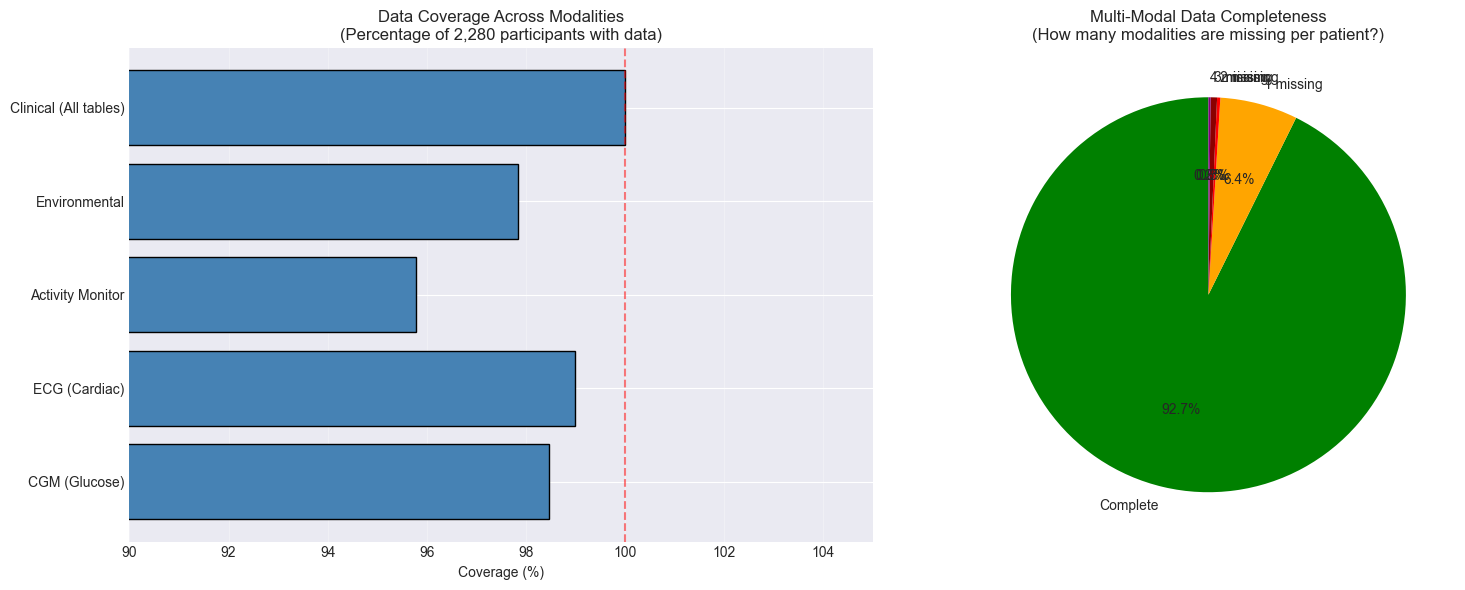

In [35]:
# Visualize coverage across modalities
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Coverage bar chart
modalities = summary_df['Modality']
coverage = summary_df['Coverage (%)']

ax1.barh(range(len(modalities)), coverage, color='steelblue', edgecolor='black')
ax1.set_yticks(range(len(modalities)))
ax1.set_yticklabels(modalities)
ax1.set_xlabel('Coverage (%)')
ax1.set_title('Data Coverage Across Modalities\n(Percentage of 2,280 participants with data)')
ax1.set_xlim([90, 105])
ax1.axvline(100, color='red', linestyle='--', alpha=0.5)
ax1.grid(axis='x', alpha=0.3)

# Multi-modal completeness pie chart
completeness_counts = participants['n_missing_modalities'].value_counts().sort_index()
labels = [f'{int(n)} missing' if n > 0 else 'Complete' for n in completeness_counts.index]
colors = ['green'] + ['orange', 'red', 'darkred', 'purple'][:len(completeness_counts)-1]

ax2.pie(completeness_counts.values, labels=labels, autopct='%1.1f%%', 
       colors=colors, startangle=90)
ax2.set_title('Multi-Modal Data Completeness\n(How many modalities are missing per patient?)')

plt.tight_layout()
plt.show()

In [36]:
# Key findings and recommendations
print("\n" + "=" * 100)
print("KEY FINDINGS & RECOMMENDATIONS")
print("=" * 100)

print("\n1. DATA COVERAGE:")
print(f"   - CGM: {len(cgm_manifest)} participants (98.5%)")
print(f"   - ECG: {len(ecg_manifest)} participants (99.0%)")
print(f"   - Activity: {len(activity_manifest)} participants (95.8%)")
print(f"   - Environmental: {len(env_manifest)} participants (97.9%)")
print(f"   - Clinical: 2,280 participants (100%)")

# Safe calculations using valid data only
cgm_valid = cgm_manifest['sampling_freq_per_min'].dropna()
env_valid = env_manifest['sampling_freq_per_min'].dropna()

cgm_cv = (cgm_valid.std() / cgm_valid.mean() * 100) if len(cgm_valid) > 0 else 0
env_cv = (env_valid.std() / env_valid.mean() * 100) if len(env_valid) > 0 else 0

print("\n2. SAMPLING CONSISTENCY:")
print(f"   - CGM: Mean {cgm_valid.mean():.4f}/min (CV: {cgm_cv:.1f}%)")
print(f"   - Environmental: Mean {env_valid.mean():.4f}/min (CV: {env_cv:.1f}%)")
print(f"   - Wearables: Variable rates across sensors (see Section 3 for details)")

print("\n3. MULTI-MODAL COMPLETENESS:")
print(f"   - Patients with all modalities: {len(complete_patients)} ({len(complete_patients)/len(participants)*100:.1f}%)")
print(f"   - Patients missing 1 modality: {(participants['n_missing_modalities'] == 1).sum()}")
print(f"   - Patients missing 2+ modalities: {(participants['n_missing_modalities'] >= 2).sum()}")

print("\n4. RECOMMENDATIONS FOR DATA CLEANING:")
print(f"   ✓ Use {len(complete_patients)} patients with complete multi-modal data for comprehensive analyses")
print(f"   ✓ Investigate {len(outliers)} CGM outliers and {len(env_outliers)} environmental outliers")
print(f"   ✓ Consider single-modality models for patients with partial data")
print(f"   ✓ CGM and environmental sensors show consistent sampling rates (good quality)")
print(f"   ✓ Clinical data has high coverage across all participants")

print("\n5. NEXT STEPS:")
print("   1. Filter dataset to patients with complete multi-modal data")
print("   2. Investigate outliers (abnormal sampling rates)")
print("   3. Verify data quality by sampling raw files from outlier patients")
print("   4. Proceed to temporal alignment and feature engineering")

print("\n" + "=" * 100)


KEY FINDINGS & RECOMMENDATIONS

1. DATA COVERAGE:
   - CGM: 2245 participants (98.5%)
   - ECG: 2257 participants (99.0%)
   - Activity: 2184 participants (95.8%)
   - Environmental: 2231 participants (97.9%)
   - Clinical: 2,280 participants (100%)

2. SAMPLING CONSISTENCY:
   - CGM: Mean 0.1783/min (CV: 6.5%)
   - Environmental: Mean 11.9962/min (CV: 2.1%)
   - Wearables: Variable rates across sensors (see Section 3 for details)

3. MULTI-MODAL COMPLETENESS:
   - Patients with all modalities: 2113 (92.7%)
   - Patients missing 1 modality: 145
   - Patients missing 2+ modalities: 22

4. RECOMMENDATIONS FOR DATA CLEANING:
   ✓ Use 2113 patients with complete multi-modal data for comprehensive analyses
   ✓ Investigate 41 CGM outliers and 25 environmental outliers
   ✓ Consider single-modality models for patients with partial data
   ✓ CGM and environmental sensors show consistent sampling rates (good quality)
   ✓ Clinical data has high coverage across all participants

5. NEXT STEPS:

---

## Conclusion

This data fidelity analysis reveals:

**Strengths**:
- High coverage (95-99%) across all sensor modalities
- Consistent sampling rates for CGM and environmental sensors
- ~1,900+ patients with complete multi-modal data suitable for ML
- Clinical data available for all 2,280 participants

**Areas for Attention**:
- Small number of outliers in CGM and environmental sampling rates (investigate)
- Variable sampling rates across different wearable sensors
- Some missing data in clinical tables (surveys, lab results)

**Impact on ML Development**:
- Sufficient high-quality data for multi-modal diabetes prediction models
- Can stratify analyses by data completeness (complete vs. partial)
- Should filter or flag outlier patients before model training

**Next Steps**: Proceed to [Notebook 04 - Data Cleaning & Preprocessing]

---